### Ekamen 2022

In [433]:
#general packages:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from seaborn import heatmap, countplot, boxplot, barplot, histplot
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,roc_auc_score, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree


from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

Binær dependant variable

In [434]:
df=pd.read_csv("Churn.csv")

In [435]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,199992.480000,1.000000


In [436]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,Female,42,2,0.00,1,Yes,1,101348.88,1
1,608,Female,41,1,83807.86,1,No,1,112542.58,0
2,502,Female,42,8,159660.80,3,Yes,0,113931.57,1
3,699,Female,39,1,0.00,2,No,0,93826.63,0
4,850,Female,43,2,125510.82,1,Yes,1,79084.10,0


In [437]:
df.tail()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
9995,771,Male,39,5,0.00,2,Yes,0,96270.64,0
9996,516,Male,35,10,57369.61,1,Yes,1,101699.77,0
9997,709,Female,36,7,0.00,1,No,1,42085.58,1
9998,772,Male,42,3,75075.31,2,Yes,0,92888.52,1
9999,792,Female,28,4,130142.79,1,Yes,0,38190.78,0


In [438]:
df.NumOfProducts.value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [439]:
df.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Churn              0
dtype: int64

In [440]:
print(len(df))

10000


ingen tomme verdier

In [441]:
df.HasCrCard.unique()

array(['Yes', 'No'], dtype=object)

In [442]:
df.IsActiveMember.unique()

array([1, 0])

In [443]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [444]:
df.Gender.value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

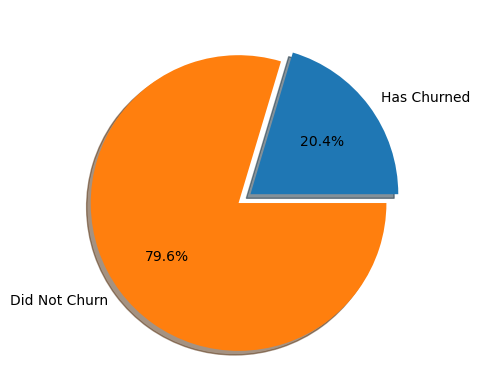

In [445]:
Churned = df["Churn"].value_counts().iloc[1]
not_churned=df["Churn"].value_counts().iloc[0]

plt.pie([Churned, not_churned],
         labels= ["Has Churned", "Did Not Churn"],
        explode =(0, 0.1),
        autopct="%1.1f%%",
        shadow=True
       )
plt.show()


In [446]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Gender           10000 non-null  object 
 2   Age              10000 non-null  int64  
 3   Tenure           10000 non-null  int64  
 4   Balance          10000 non-null  float64
 5   NumOfProducts    10000 non-null  int64  
 6   HasCrCard        10000 non-null  object 
 7   IsActiveMember   10000 non-null  int64  
 8   EstimatedSalary  10000 non-null  float64
 9   Churn            10000 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 781.4+ KB


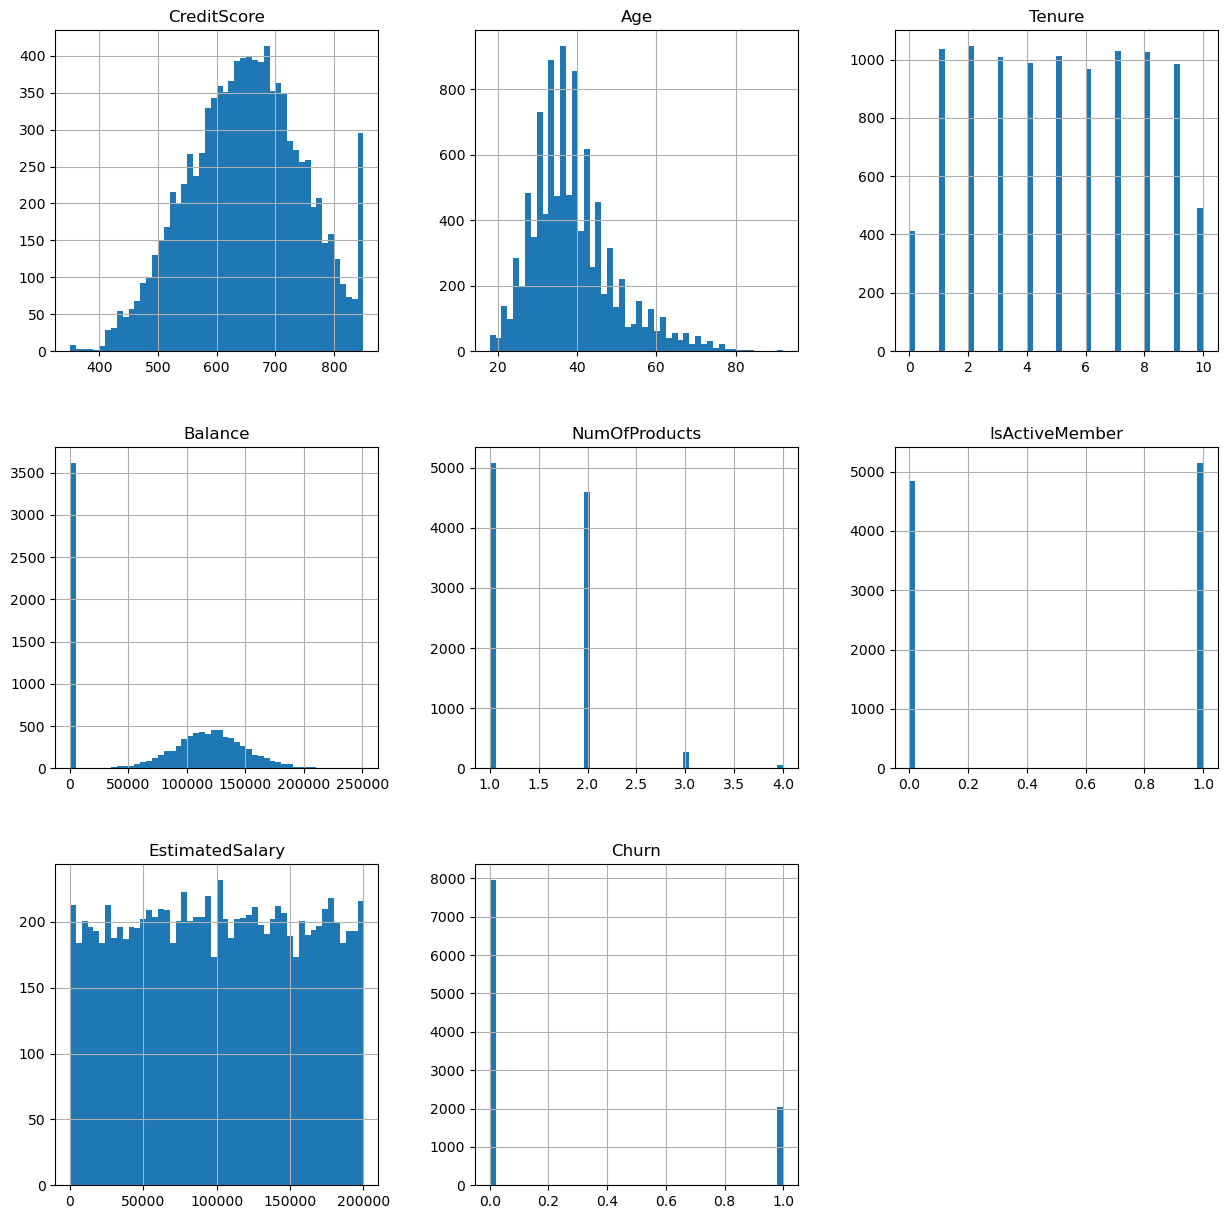

In [447]:
df.hist(bins=50, figsize=(15,15))
plt.show()


<Axes: >

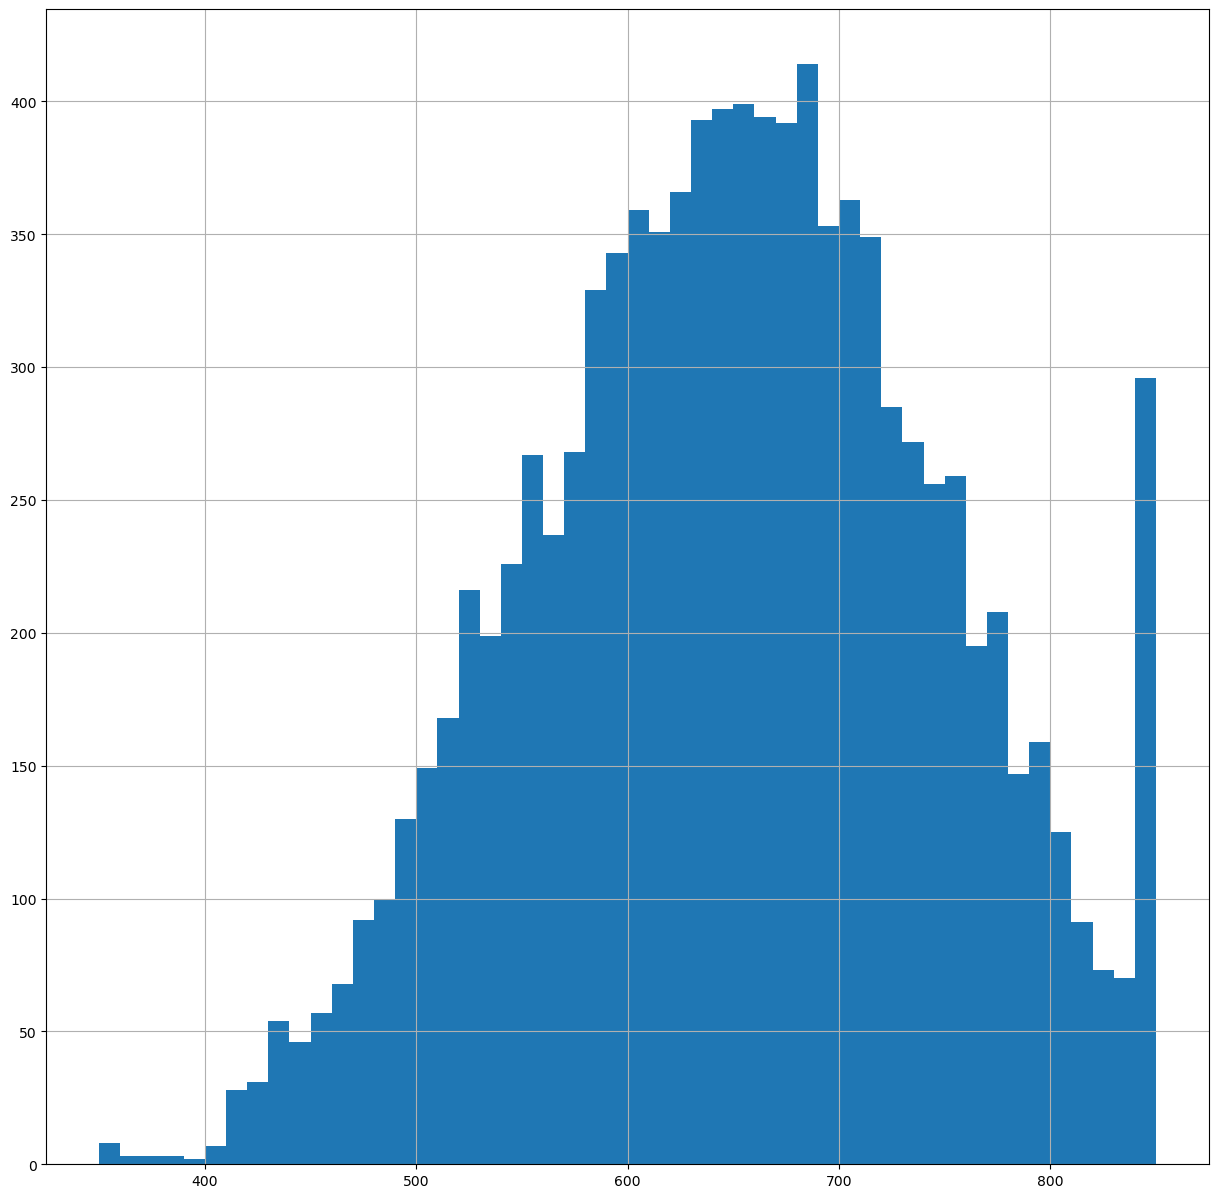

In [448]:
df.CreditScore.hist(bins=50, figsize=(15,15))

In [449]:
df["CreditScore"].value_counts()[850]

233

### ser at vi finner potensielt noen verdier som kan skape feil i prediksjonen vår. derfor velger jeg å fjerne de, slik at det ikke blir skjevheter

In [450]:
#df=df[df["CreditScore"] < 850]
#df=df[df["Balance"] >0]

In [451]:
#df[["CreditScore", "Balance"]].hist(bins=50, figsize=(10,5))
#plt.show()

In [452]:
print("new length of the dataset after removing outliers:", len(df))

new length of the dataset after removing outliers: 10000


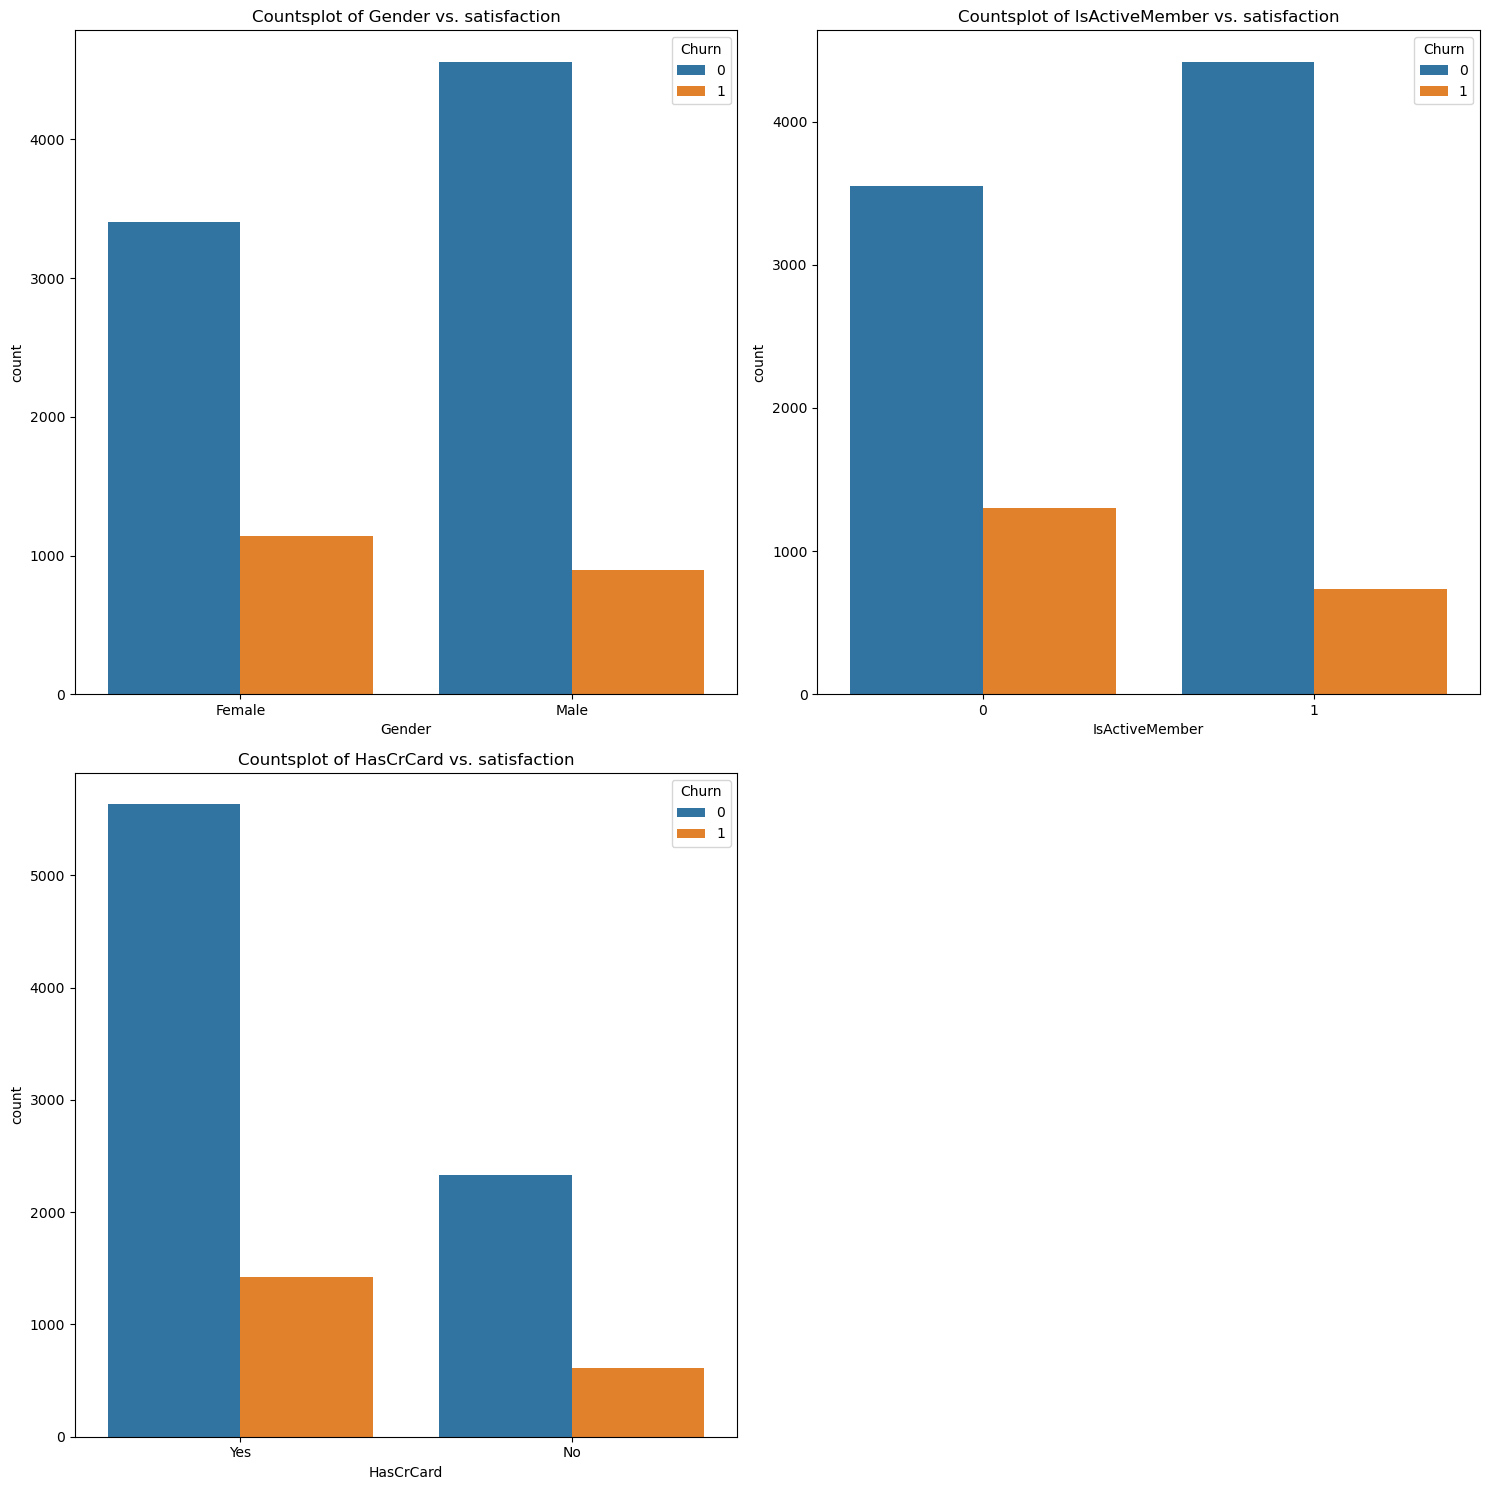

In [453]:
categorical_var= ["Gender", "IsActiveMember", "HasCrCard"]

plt.figure(figsize=(15,15))
for i, var in enumerate(categorical_var, 1):
    plt.subplot(2,2,i)
    countplot(x=var, hue="Churn", data=df)
    plt.title(f"Countsplot of {var} vs. satisfaction")

plt.tight_layout()
plt.show()

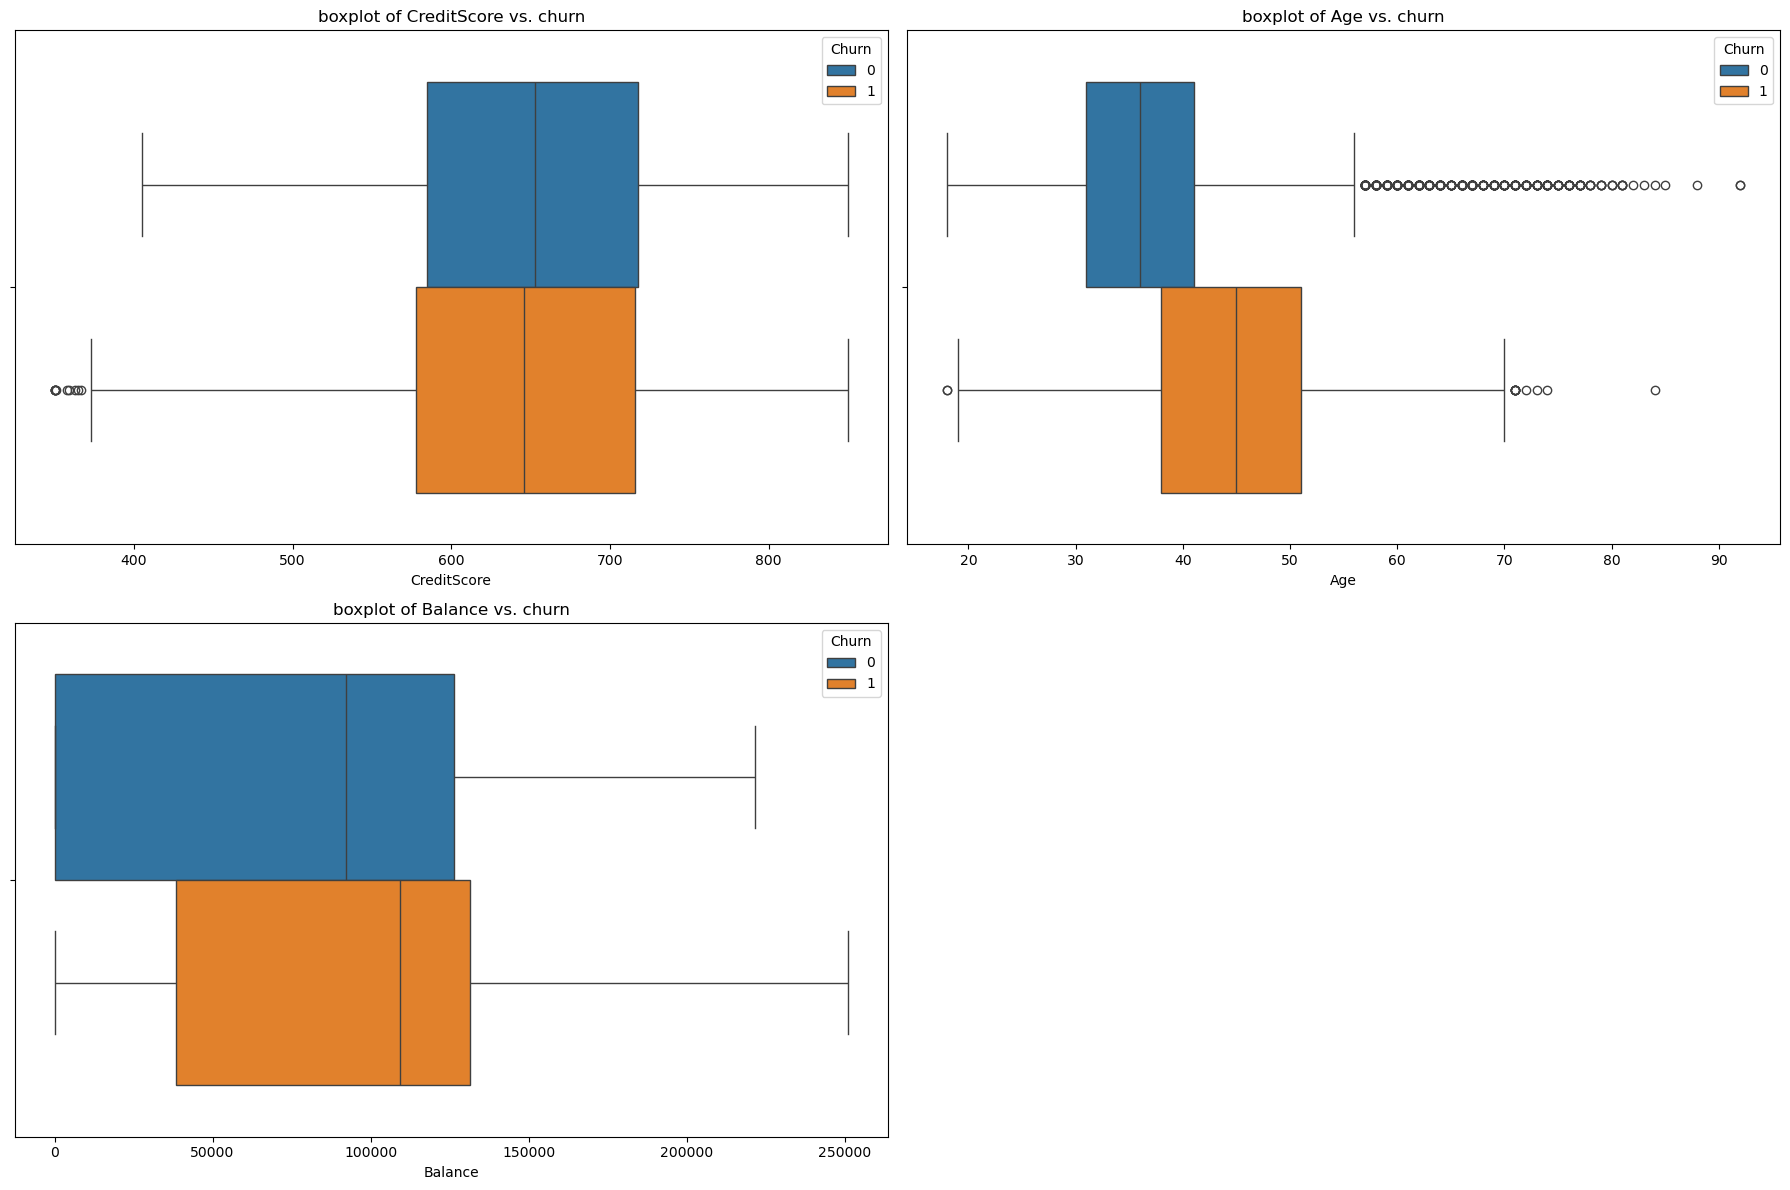

In [454]:
Kont_var= ["CreditScore", "Age", "Balance"]

plt.figure(figsize=(18,12))
for i, var in enumerate(Kont_var, 1):
    plt.subplot(2,2,i)
    boxplot(x=var, hue="Churn", data=df)
    plt.title(f"boxplot of {var} vs. churn")

plt.tight_layout()
plt.show()

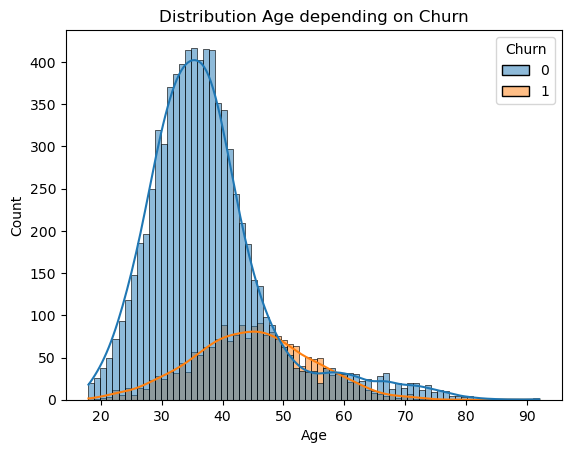

In [455]:
histplot(data=df, x="Age", hue="Churn", kde=True, bins=75)
plt.title("Distribution Age depending on Churn")
plt.show()

### Encoding:
- we need to encode some of the variables in the dataset, so that we can actually use the variables and get accurate predictions

In [456]:
df.HasCrCard.unique()


array(['Yes', 'No'], dtype=object)

In [457]:
df.IsActiveMember.unique()


array([1, 0])

In [458]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [459]:
df_dummies=pd.get_dummies(df, drop_first=True, dtype=int)

In [460]:
df_dummies.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Churn,Gender_Male,HasCrCard_Yes
0,619,42,2,0.00,1,1,101348.88,1,0,1
1,608,41,1,83807.86,1,1,112542.58,0,0,0
2,502,42,8,159660.80,3,0,113931.57,1,0,1
3,699,39,1,0.00,2,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,79084.10,0,0,1


In [461]:
df=df_dummies

In [462]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Churn,Gender_Male,HasCrCard_Yes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.515100,100090.239881,0.203700,0.545700,0.70550
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.499797,57510.492818,0.402769,0.497932,0.45584
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,11.580000,0.000000,0.000000,0.00000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,51002.110000,0.000000,0.000000,0.00000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,100193.915000,0.000000,1.000000,1.00000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.000000,149388.247500,0.000000,1.000000,1.00000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,199992.480000,1.000000,1.000000,1.00000


In [463]:
corr_df= df.corr().Churn.sort_values(ascending=False)

In [464]:
print(corr_df[1:])

Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard_Yes     -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender_Male       -0.106512
IsActiveMember    -0.156128
Name: Churn, dtype: float64


In [465]:
corr_df=df[["CreditScore", "Age",	"Tenure", 
            "Balance", "NumOfProducts", "IsActiveMember", "EstimatedSalary", "Churn"]]


            

ser at det er svake korrelasjoner mellom churn og de avhengige variablene

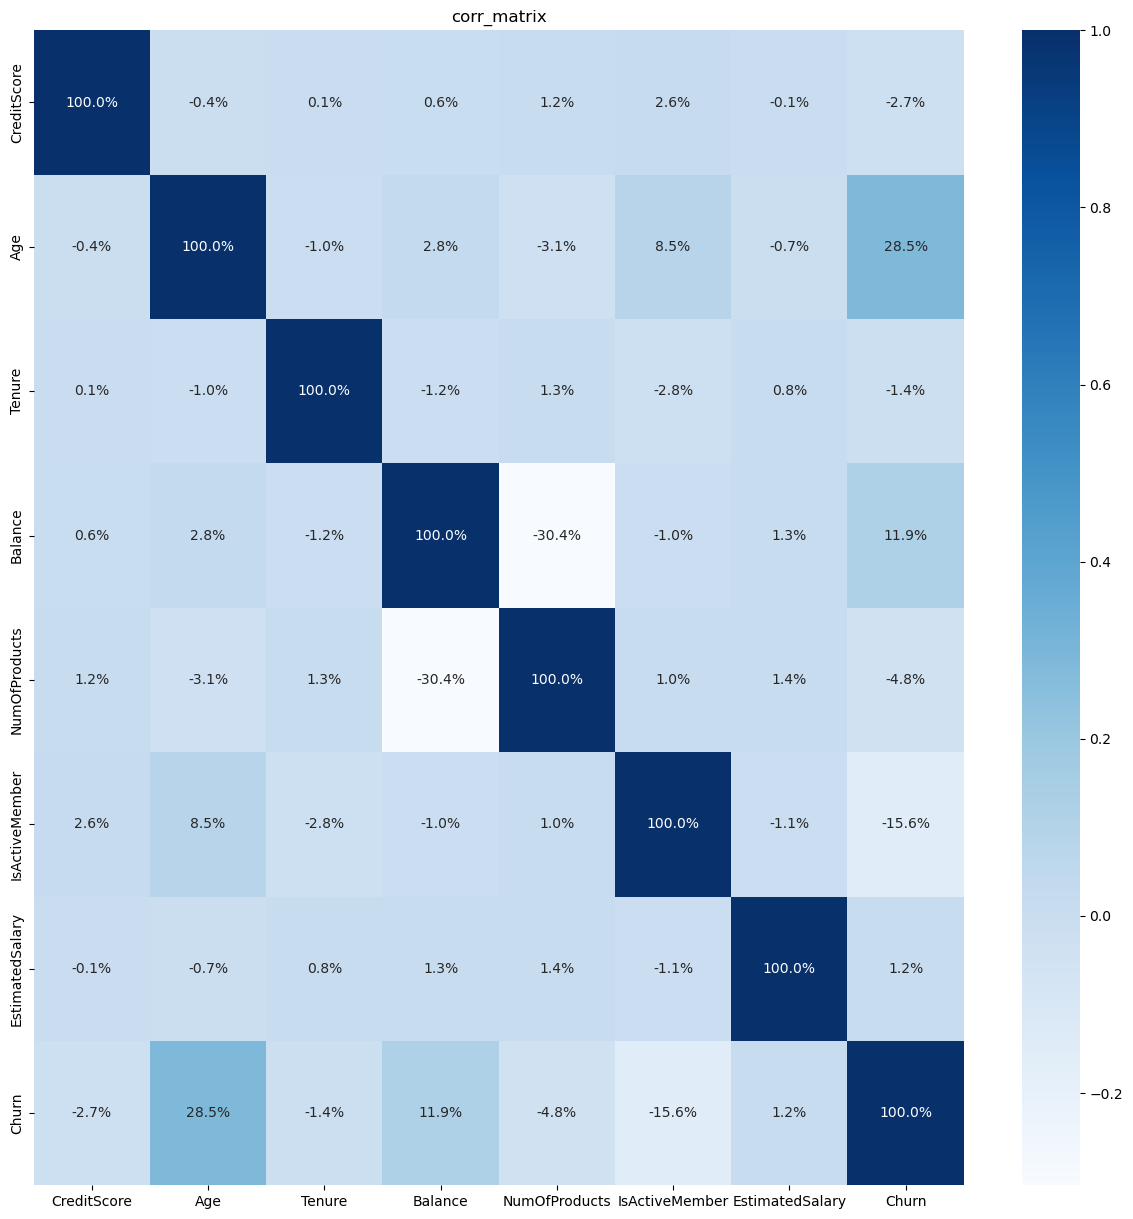

In [466]:
cm=corr_df.corr()

plt.figure(figsize=(15,15))
heatmap(cm, annot =True, fmt= ".1%", cmap="Blues")
plt.title("corr_matrix")
plt.show()

so far the main feature that is most relevant, and correlates the most with the churn, is the age. the older you get, the more likely it is to switch banks. this makes sense, due to the fact that younger people tend to not switch banks due to stability.

In [467]:
corr= corr_df.corr()
corr=abs(corr)
corr = corr.Churn.sort_values(ascending=False)

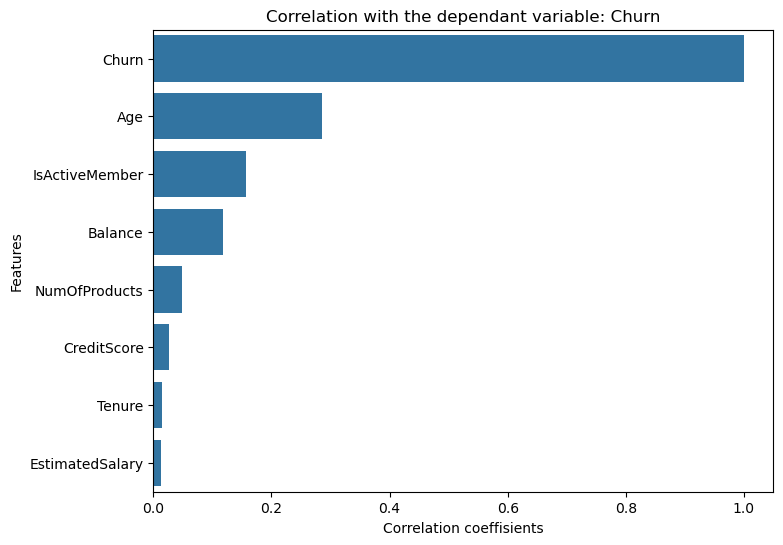

In [468]:
plt.figure(figsize=(8,6))
barplot(x=corr.values, y=corr.index)
plt.title("Correlation with the dependant variable: Churn")
plt.xlabel("Correlation coeffisients")
plt.ylabel("Features")
plt.show()

In [469]:
df= corr_df

### scatter plot:

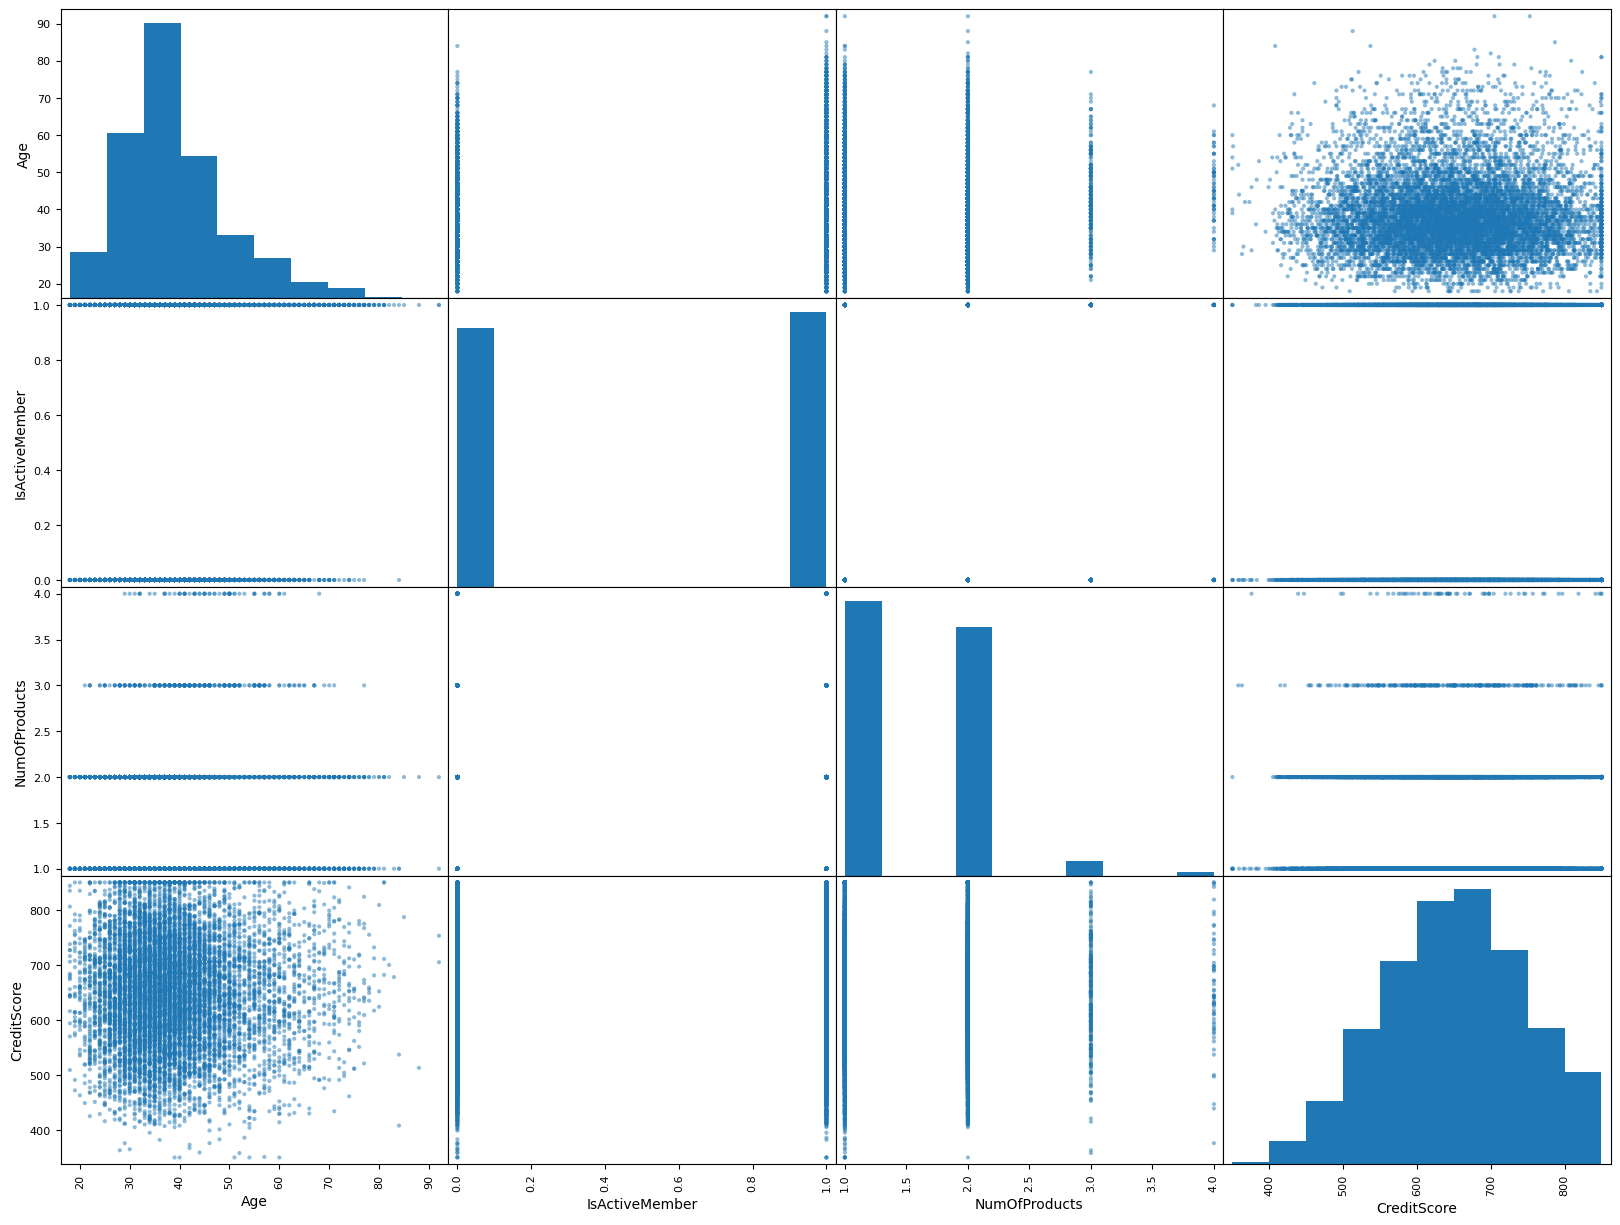

In [470]:
scatter_df= df[["Age", "IsActiveMember", "NumOfProducts", "CreditScore"]]
pd.plotting.scatter_matrix(scatter_df, figsize=(20,15))
plt.show()

lite informasjon som gis

## Prepare the data:

### creates the X and Y variable:

In [471]:
X= df.drop(["Churn"], axis=1)
y=df["Churn"]

In [472]:
print(len(X))
print(len(y))

10000
10000


In [473]:
y.value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

#### lets scale the values!

In [474]:
#creates the scaler:
X_scaler = MinMaxScaler(feature_range=(0,1))

# scaling the X variables:

X_sc = X_scaler.fit_transform(X)

#putting the scaled X back in the dataframe:
X_sc= pd.DataFrame(X_sc, columns = X.columns)
X=X_sc


In [475]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary
0,0.538,0.324324,0.2,0.000000,0.000000,1.0,0.506735
1,0.516,0.310811,0.1,0.334031,0.000000,1.0,0.562709
2,0.304,0.324324,0.8,0.636357,0.666667,0.0,0.569654
3,0.698,0.283784,0.1,0.000000,0.333333,0.0,0.469120
4,1.000,0.337838,0.2,0.500246,0.000000,1.0,0.395400


#### splitting the dataset into a training and a test set:

In [544]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 42)

In [545]:
X_train_original=X_train.copy()
X_test_original=X_test.copy()

In [546]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary
9254,0.672,0.189189,0.6,0.000000,0.333333,1.0,0.895494
1561,0.564,0.324324,0.4,0.476786,0.333333,1.0,0.979930
1670,0.418,0.081081,0.3,0.457317,0.000000,0.0,0.429438
6087,0.422,0.121622,0.9,0.540606,0.000000,0.0,0.765417
6669,0.334,0.513514,0.9,0.566554,0.000000,0.0,0.197401


In [547]:
print(len(X_train))

8000


# Model 1: Logistic Regression

In [548]:
model_LR = LogisticRegression()

In [549]:
model_LR= model_LR.fit(X_train, y_train)

In [550]:
y_train_pred= model_LR.predict(X_train)

In [551]:
y_test_pred= model_LR.predict(X_test)

In [552]:
train_Acc= round(accuracy_score(y_train_pred, y_train),4)
test_Acc = round(accuracy_score(y_test_pred, y_test), 4)

print("The Accuracy score in the training set is:", train_Acc)
print("The Accuracy Score in the test set is:", test_Acc)

The Accuracy score in the training set is: 0.8063
The Accuracy Score in the test set is: 0.81


we see that the model score is prediction ok on bot the training set and the test set. the training set is a bit higher, which might mean overfitting, and a bit noise in the training set, but the difference is very low.

### putting the predictions in a scatterplot:

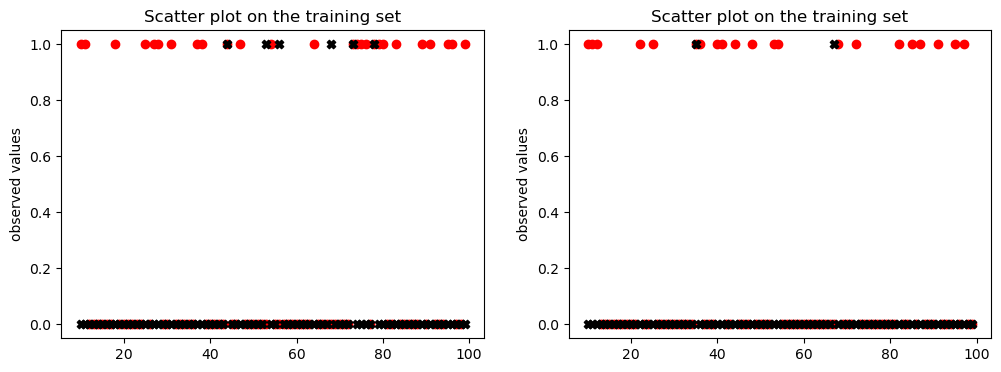

In [553]:
start= 10
stop = 100
x_axis = list(range(start, stop))

fig, ax = plt.subplots(1,2,figsize= (12,4))

#scatter plot on the train set:
ax[0].scatter(x_axis, y_train[start:stop], c="red")
ax[0].scatter(x_axis, y_train_pred[start:stop], c="black", marker="X")
ax[0].set_title("Scatter plot on the training set")
ax[0].set_xlabel:("Predicted values")
ax[0].set_ylabel("observed values")


ax[1].scatter(x_axis, y_test[start:stop], c="red")
ax[1].scatter(x_axis, y_test_pred[start:stop], c="black", marker="X")
ax[1].set_title("Scatter plot on the training set")
ax[1].set_xlabel:("Predicted values")
ax[1].set_ylabel("observed values")

plt.show()

### much overlapping. difficult to see, but we see that the classicifation is not perfect. easier to see in a confusion matrix

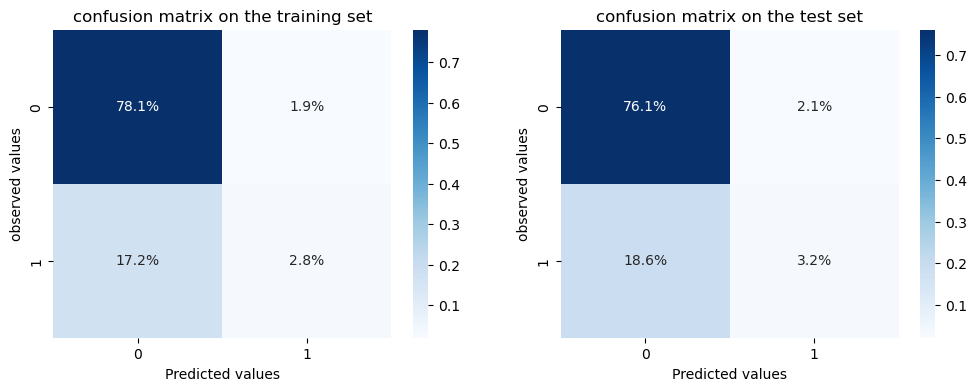

In [486]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1,2,figsize= (12,4))
heatmap(cm_train/np.sum(cm_train), annot=True, fmt=".1%", cmap="Blues", ax=ax[0])
ax[0].set_title("confusion matrix on the training set")
ax[0].set_xlabel("Predicted values")
ax[0].set_ylabel("observed values")

heatmap(cm_test/np.sum(cm_test), annot=True, fmt=".1%", cmap="Blues", ax=ax[1])
ax[1].set_title("confusion matrix on the test set")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("observed values")


plt.show()


we see that the model does not classify the members as we hoped, it could be lethal if we have big bank with a lot of members.
- the model predicts that 72,6% are correctly classified, the people that was predicted to stay, did in fact stay. the true negatives
- 
- the model predicts that 4,7% are correctly classified: the people that are predicted to leave, did in fact leave. the true positives
  
- the model predics that 19,9% of the people that left the bank, but were predicted to stay. the most lethal one., the False negative
  
- the model predicts that 2,7% of the people that are predicted to leave, did in fact stay.
- false positive 



### the ROC_Curve visualized:

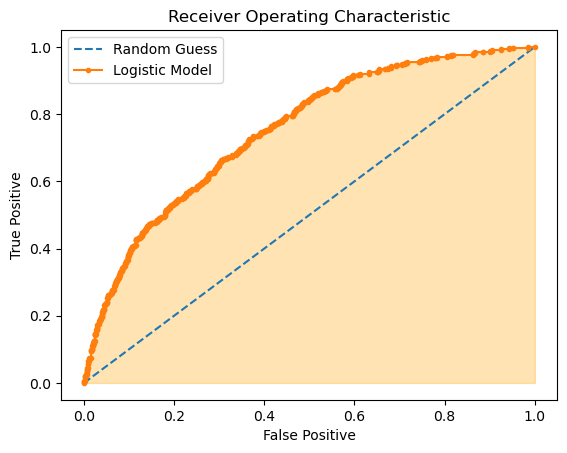

In [487]:
#Plotting the ROC curve:
log_y_prob = model_LR.predict_proba(X_test)

#limiting the possibility of predicting ones:
log_y_prob = log_y_prob[:,1]

#Plotting the line where the true positives = False positives, the line is just random guess, and anything above is better


plt.plot([0,1], [0,1], linestyle="--", label= "Random Guess")

fpr, tpr, thres = roc_curve(y_test, log_y_prob)

plt.plot(fpr, tpr,marker=".", label = "Logistic Model")
plt.fill_between(fpr, tpr, step = "post", color="orange", alpha=.3)
plt.ylabel("True Positive")
plt.xlabel("False Positive")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()








In [488]:
AUC = round(roc_auc_score(y_test, log_y_prob), 4)
print("the area under the curve has a value of:", AUC)

the area under the curve has a value of: 0.7511


In [489]:
summary_dict= {"Model": ["Logistic Model 1"],
               "Train Accuracy": [train_Acc],
               "Test Accuracy": [test_Acc],
               "AUC" : [AUC]}
summary_df = pd.DataFrame(summary_dict)

In [490]:
summary_df

,Model,Train Accuracy,Test Accuracy,AUC
0,Logistic Model 1,0.8091,0.793,0.7511


### evaluate the most importance features:

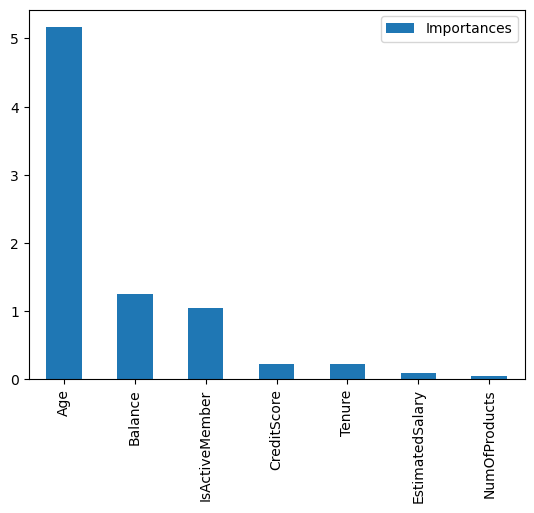

In [491]:
coefficients = []

for coeff in model_LR.coef_[0]:
    coefficients.append(abs(coeff))

feature_importances = pd.DataFrame(coefficients, 
                                   index=X.columns, columns = ["Importances"])

feature_importances.sort_values(by=["Importances"],
                                axis=0, ascending = False, inplace=True)

feature_importances.head(7).plot(kind="bar")
plt.show()

##### we want to see if we can get a higher accuracy on both the train and test set, and see if we can classify the customers better. therefore we choose just a handful of variables, to see if it means anything:

In [492]:
Var_list= ["Age", "IsActiveMember", "NumOfProducts"]

X_train = X_train[Var_list]
X_test = X_test[Var_list]

In [493]:
model_LR=LogisticRegression(max_iter=1000)

In [494]:
model_LR= model_LR.fit(X_train, y_train)

In [495]:
y_test_pred = model_LR.predict(X_test)
y_train_pred = model_LR.predict(X_train)

In [496]:
train_Acc= round(accuracy_score(y_train_pred, y_train),4)
test_Acc = round(accuracy_score(y_test_pred, y_test), 4)

print("The Accuracy score in the training set is:", train_Acc)
print("The Accuracy Score in the test set is:", test_Acc)

The Accuracy score in the training set is: 0.8056
The Accuracy Score in the test set is: 0.791


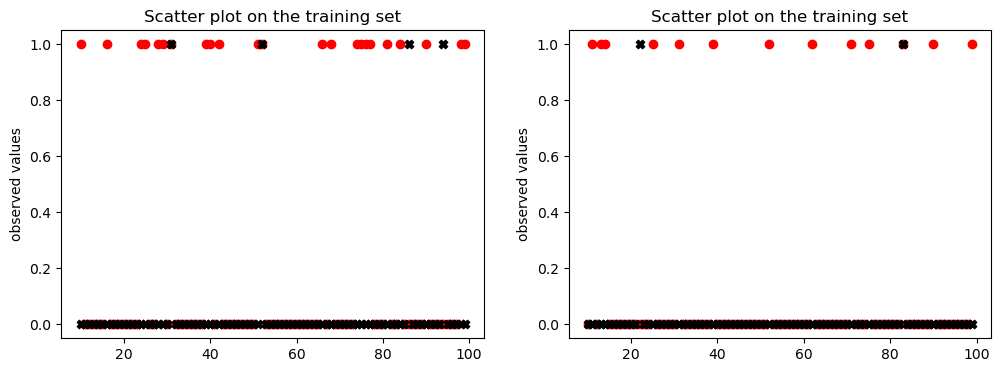

In [497]:
start= 10
stop = 100
x_axis = list(range(start, stop))

fig, ax = plt.subplots(1,2,figsize= (12,4))

#scatter plot on the train set:
ax[0].scatter(x_axis, y_train[start:stop], c="red")
ax[0].scatter(x_axis, y_train_pred[start:stop], c="black", marker="X")
ax[0].set_title("Scatter plot on the training set")
ax[0].set_xlabel:("Predicted values")
ax[0].set_ylabel("observed values")


ax[1].scatter(x_axis, y_test[start:stop], c="red")
ax[1].scatter(x_axis, y_test_pred[start:stop], c="black", marker="X")
ax[1].set_title("Scatter plot on the training set")
ax[1].set_xlabel:("Predicted values")
ax[1].set_ylabel("observed values")

plt.show()

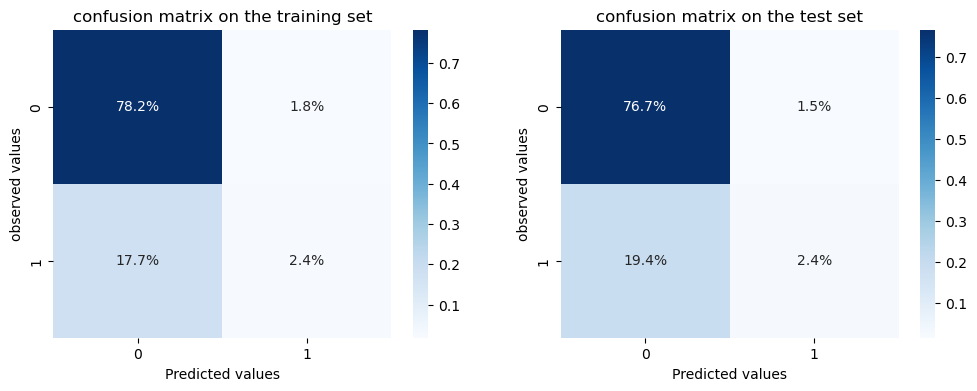

In [498]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1,2,figsize= (12,4))
heatmap(cm_train/np.sum(cm_train), annot=True, fmt=".1%", cmap="Blues", ax=ax[0])
ax[0].set_title("confusion matrix on the training set")
ax[0].set_xlabel("Predicted values")
ax[0].set_ylabel("observed values")

heatmap(cm_test/np.sum(cm_test), annot=True, fmt=".1%", cmap="Blues", ax=ax[1])
ax[1].set_title("confusion matrix on the test set")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("observed values")


plt.show()


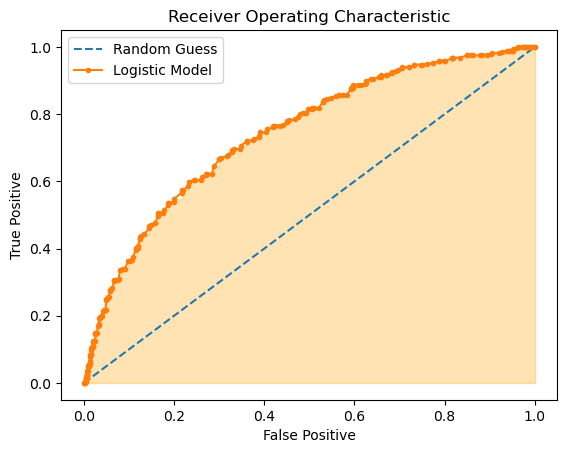

In [499]:
#Plotting the ROC curve:
log_y_prob = model_LR.predict_proba(X_test)

#limiting the possibility of predicting ones:
log_y_prob = log_y_prob[:,1]

#Plotting the line where the true positives = False positives, the line is just random guess, and anything above is better


plt.plot([0,1], [0,1], linestyle="--", label= "Random Guess")

fpr, tpr, thres = roc_curve(y_test, log_y_prob)

plt.plot(fpr, tpr,marker=".", label = "Logistic Model")
plt.fill_between(fpr, tpr, step = "post", color="orange", alpha=.3)
plt.ylabel("True Positive")
plt.xlabel("False Positive")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()


In [500]:
AUC = round(roc_auc_score(y_test, log_y_prob), 4)
print("the area under the curve has a value of:", AUC)

the area under the curve has a value of: 0.7436


In [501]:
summary_dict= {"Model": ["Logistic Model 2"],
               "Train Accuracy": [train_Acc],
               "Test Accuracy": [test_Acc],
               "AUC" : [AUC]}
Add_df = pd.DataFrame(summary_dict)
summary_df = pd.concat([summary_df, Add_df], ignore_index=True)

In [502]:
summary_df

,Model,Train Accuracy,Test Accuracy,AUC
0,Logistic Model 1,0.8091,0.793,0.7511
1,Logistic Model 2,0.8056,0.791,0.7436


## Model 2: Naive Bayes:
- classification!

In [503]:
model_NB = GaussianNB()

In [504]:
X_train = X_train_original.copy()
X_test = X_test_original.copy()

In [505]:
model_NB = model_NB.fit(X_train, y_train)

In [506]:
y_train_pred = model_NB.predict(X_train)
y_test_pred = model_NB.predict(X_test)

In [507]:
train_Acc= round(accuracy_score(y_train_pred, y_train),4)
test_Acc = round(accuracy_score(y_test_pred, y_test), 4)

print("The Accuracy score in the training set is:", train_Acc)
print("The Accuracy Score in the test set is:", test_Acc)

The Accuracy score in the training set is: 0.8266
The Accuracy Score in the test set is: 0.8095


### Scatter plots Naive bayes:

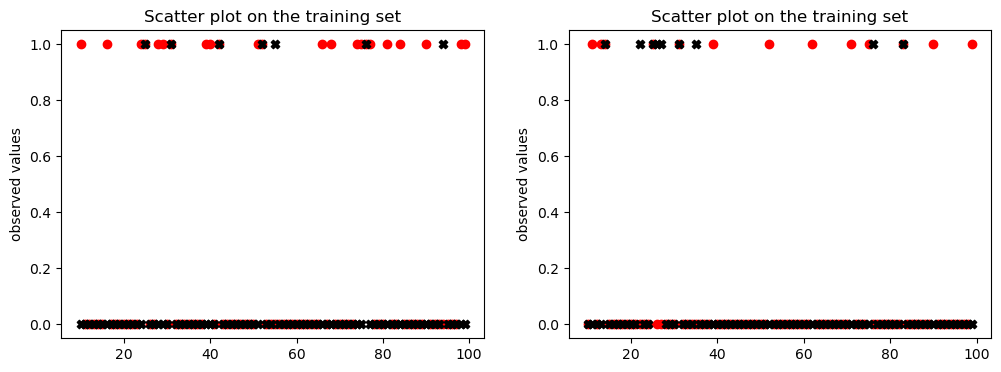

In [508]:
start= 10
stop = 100
x_axis = list(range(start, stop))

fig, ax = plt.subplots(1,2,figsize= (12,4))

#scatter plot on the train set:
ax[0].scatter(x_axis, y_train[start:stop], c="red")
ax[0].scatter(x_axis, y_train_pred[start:stop], c="black", marker="X")
ax[0].set_title("Scatter plot on the training set")
ax[0].set_xlabel:("Predicted values")
ax[0].set_ylabel("observed values")


ax[1].scatter(x_axis, y_test[start:stop], c="red")
ax[1].scatter(x_axis, y_test_pred[start:stop], c="black", marker="X")
ax[1].set_title("Scatter plot on the training set")
ax[1].set_xlabel:("Predicted values")
ax[1].set_ylabel("observed values")

plt.show()

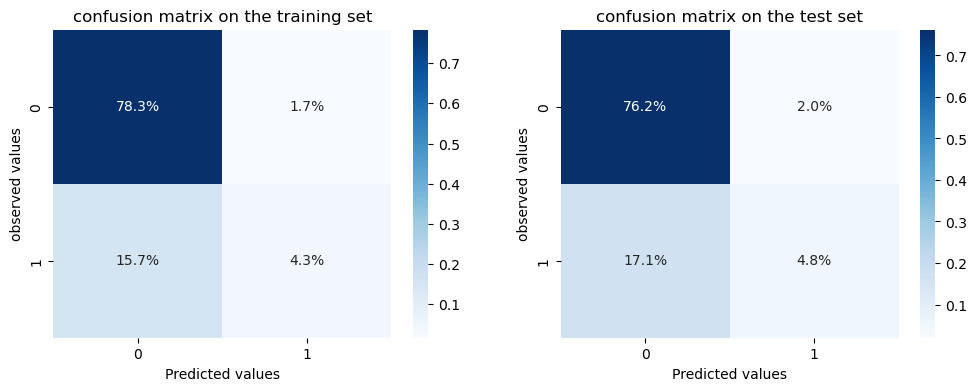

In [509]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1,2,figsize= (12,4))
heatmap(cm_train/np.sum(cm_train), annot=True, fmt=".1%", cmap="Blues", ax=ax[0])
ax[0].set_title("confusion matrix on the training set")
ax[0].set_xlabel("Predicted values")
ax[0].set_ylabel("observed values")

heatmap(cm_test/np.sum(cm_test), annot=True, fmt=".1%", cmap="Blues", ax=ax[1])
ax[1].set_title("confusion matrix on the test set")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("observed values")


plt.show()


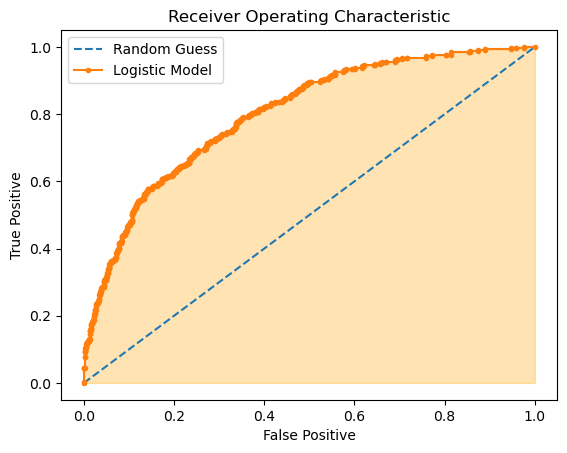

In [510]:
#Plotting the ROC curve:
log_y_prob = model_NB.predict_proba(X_test)

#limiting the possibility of predicting ones:
log_y_prob = log_y_prob[:,1]

#Plotting the line where the true positives = False positives, the line is just random guess, and anything above is better


plt.plot([0,1], [0,1], linestyle="--", label= "Random Guess")

fpr, tpr, thres = roc_curve(y_test, log_y_prob)

plt.plot(fpr, tpr,marker=".", label = "Logistic Model")
plt.fill_between(fpr, tpr, step = "post", color="orange", alpha=.3)
plt.ylabel("True Positive")
plt.xlabel("False Positive")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()

In [511]:
AUC = round(roc_auc_score(y_test, log_y_prob), 4)
print("the area under the curve has a value of:", AUC)

the area under the curve has a value of: 0.8


In [512]:
summary_dict= {"Model": ["model 2: Naive Bayes 1"],
               "Train Accuracy": [train_Acc],
               "Test Accuracy": [test_Acc],
               "AUC" : [AUC]}
Add_df = pd.DataFrame(summary_dict)
summary_df = pd.concat([summary_df, Add_df], ignore_index=True)

In [513]:
summary_df

,Model,Train Accuracy,Test Accuracy,AUC
0,Logistic Model 1,0.8091,0.7930,0.7511
1,Logistic Model 2,0.8056,0.7910,0.7436
2,model 2: Naive Bayes 1,0.8266,0.8095,0.8000


based on the metrics we can see that Naive bayes model predicts the churn possibility better than the logistic model. the train/test accuracy is higher and close to each other, and the area under the curve is also higher than model_LR

## Decision Tree Classification

In [514]:
Model_DT = DecisionTreeClassifier()

In [515]:
X_train = X_train_original.copy()
X_test = X_test_original.copy()

In [516]:
Model_DT=Model_DT.fit(X_train, y_train)

In [517]:
y_train_pred = Model_DT.predict(X_train)
y_test_pred= Model_DT.predict(X_test)


train_Acc= round(accuracy_score(y_train_pred, y_train),4)
test_Acc = round(accuracy_score(y_test_pred, y_test), 4)

print("The Accuracy score in the training set is:", train_Acc)
print("The Accuracy Score in the test set is:", test_Acc)

The Accuracy score in the training set is: 1.0
The Accuracy Score in the test set is: 0.7845


### the model is training on overfitted dataset, and we therefore need to check out different parameters and prune the tree

In [518]:
Model_DT.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [519]:
#sett max depth til enten høyere lavere
Model_DT = DecisionTreeClassifier(max_depth=10)

In [520]:
Model_DT= Model_DT.fit(X_train, y_train)

In [521]:
print("the accuracy score on the train set is:", Model_DT.score(X_train, y_train))
print("the accuracy score on the test set is:", Model_DT.score(X_test, y_test))

the accuracy score on the train set is: 0.89625
the accuracy score on the test set is: 0.835


In [522]:
Model_DT.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


we set the max_depth to 1, due to the fact that we want a smaller tree. a max_depth of 10 gives us an overfittet model, we need to go as far as down to 1 to get a more accurate score. this also means that the tree is basic without many nodes and leafs.

#### visualizing the tree:

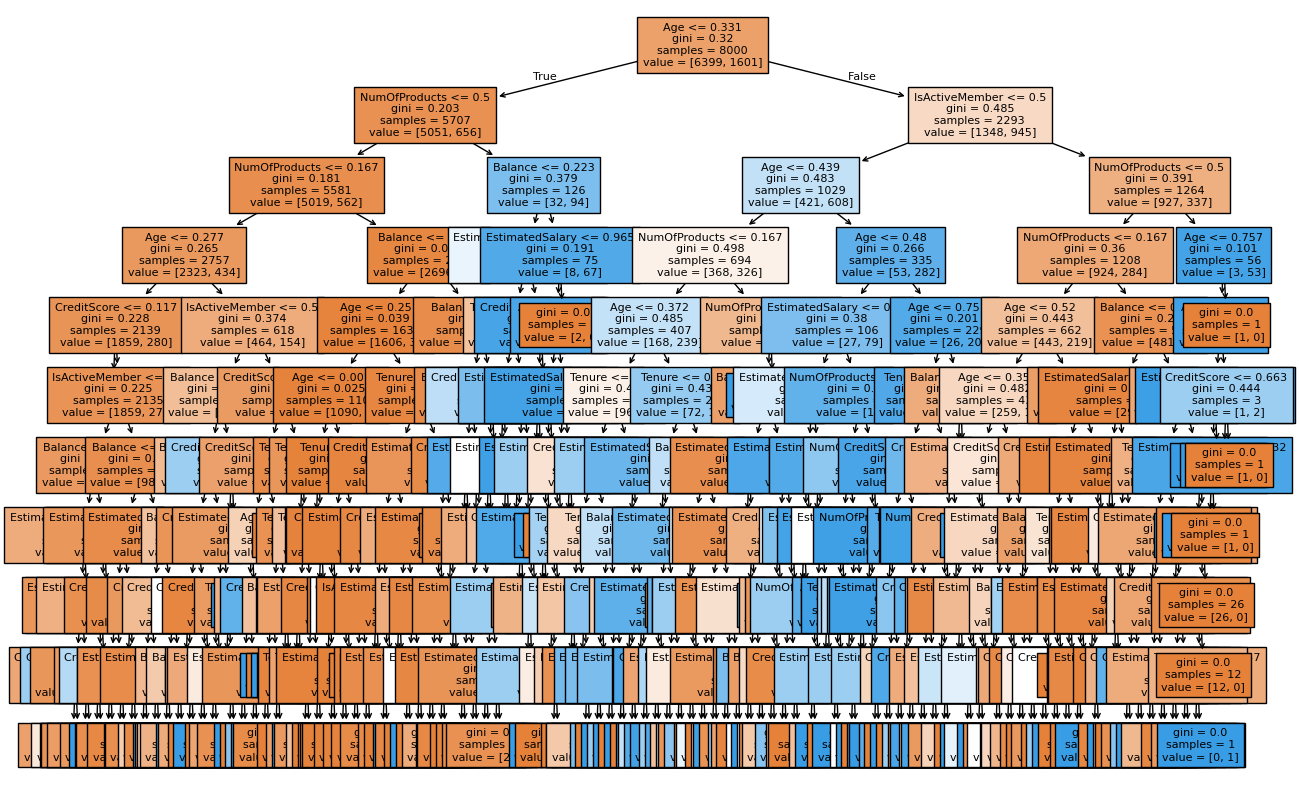

In [523]:
fig = plt.figure(figsize=(15,10))
plot_tree(Model_DT,
          feature_names = X.columns,
          filled=True,
          fontsize = 8)
plt.show()

### la oss finne optimal alpha!

In [524]:
path = Model_DT.cost_complexity_pruning_path(X_train, y_train)
dir(path)

['ccp_alphas', 'impurities']

In [525]:
ccp_alphas= path.ccp_alphas

In [526]:
model_list=[]

for alpha in ccp_alphas:
    Model_DT=DecisionTreeClassifier(ccp_alpha=alpha)
    Model_DT.fit(X_train, y_train)
    model_list.append(Model_DT)

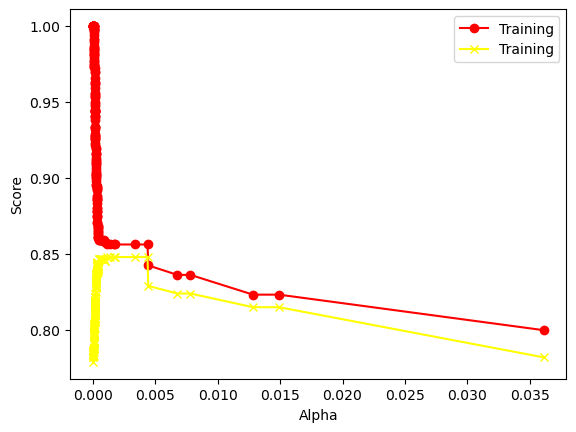

In [527]:
train_scores = [Model_DT.score(X_train, y_train) for Model_DT in model_list]
test_scores = [Model_DT.score(X_test, y_test) for Model_DT in model_list]

plt.plot(ccp_alphas, train_scores, marker = "o",
        label = "Training", color = "red")
plt.plot(ccp_alphas, test_scores, marker = "x",
        label = "Training", color = "yellow")

plt.xlabel("Alpha")
plt.ylabel("Score")
plt.legend()
plt.show()


In [528]:
Model_DT = DecisionTreeClassifier()
scores = cross_val_score(Model_DT, X_train, y_train, cv=5)
print(scores)

[0.78125  0.784375 0.770625 0.77     0.78375 ]


In [529]:
alpha_loop_values=[]

for alpha in ccp_alphas:
    Model_DT= DecisionTreeClassifier(ccp_alpha=alpha, random_state=0)
    scores=cross_val_score(Model_DT, X_train, y_train, cv=5)
    alpha_loop_values.append([alpha, np.mean(scores), np.std(scores)])


In [530]:
alpha_results = pd.DataFrame(alpha_loop_values,
                             columns=["Alpha", "Mean_Accuracy", "StDev_Accuracy"])
alpha_results.head(10)

,Alpha,Mean_Accuracy,StDev_Accuracy
0,0.000000,0.778125,0.005903
1,0.000008,0.778125,0.005903
2,0.000008,0.778125,0.005903
3,0.000019,0.778125,0.005903
4,0.000020,0.778125,0.005903
5,0.000026,0.778125,0.005903
6,0.000035,0.778125,0.005903
7,0.000042,0.778125,0.005903
8,0.000047,0.778125,0.005903
9,0.000047,0.778125,0.005903


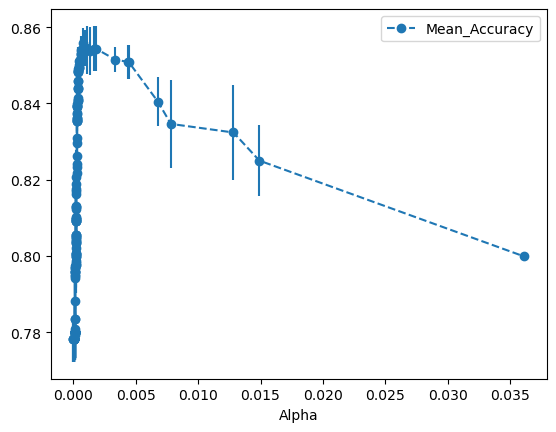

In [531]:
alpha_results.plot(x="Alpha", y="Mean_Accuracy", marker="o", linestyle="--",
                   yerr="StDev_Accuracy")
plt.show()

In [532]:
#Looking for the ideal alpha:
ideal_alpha= alpha_results[alpha_results.Mean_Accuracy==max(alpha_results.Mean_Accuracy)].Alpha
print("the ideal alpha is:", ideal_alpha)

the ideal alpha is: 143    0.000757
Name: Alpha, dtype: float64


In [533]:
ideal_alpha = ideal_alpha.item()

In [534]:
Model_DT = DecisionTreeClassifier(ccp_alpha = ideal_alpha)
Model_DT= Model_DT.fit(X_train, y_train)

In [535]:
y_train_pred = Model_DT.predict(X_train)
y_test_pred= Model_DT.predict(X_test)


train_Acc= round(accuracy_score(y_train_pred, y_train),4)
test_Acc = round(accuracy_score(y_test_pred, y_test), 4)

print("The Accuracy score in the training set is:", train_Acc)
print("The Accuracy Score in the test set is:", test_Acc)

The Accuracy score in the training set is: 0.859
The Accuracy Score in the test set is: 0.847


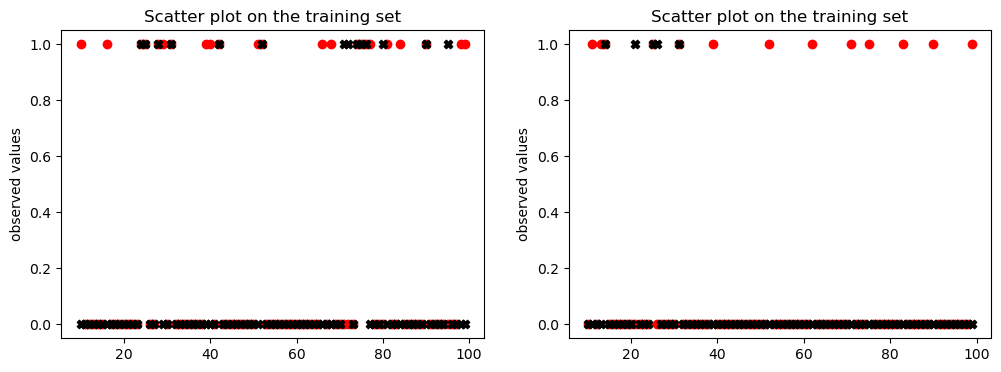

In [536]:
start= 10
stop = 100
x_axis = list(range(start, stop))

fig, ax = plt.subplots(1,2,figsize= (12,4))

#scatter plot on the train set:
ax[0].scatter(x_axis, y_train[start:stop], c="red")
ax[0].scatter(x_axis, y_train_pred[start:stop], c="black", marker="X")
ax[0].set_title("Scatter plot on the training set")
ax[0].set_xlabel:("Predicted values")
ax[0].set_ylabel("observed values")


ax[1].scatter(x_axis, y_test[start:stop], c="red")
ax[1].scatter(x_axis, y_test_pred[start:stop], c="black", marker="X")
ax[1].set_title("Scatter plot on the training set")
ax[1].set_xlabel:("Predicted values")
ax[1].set_ylabel("observed values")

plt.show()

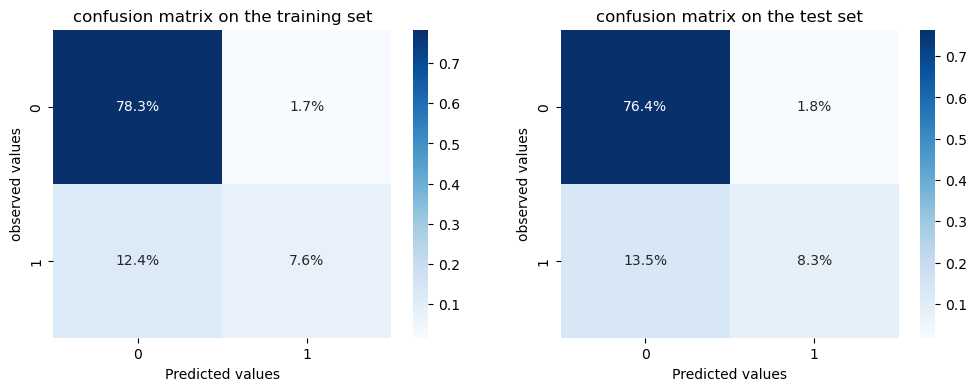

In [537]:
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1,2,figsize= (12,4))
heatmap(cm_train/np.sum(cm_train), annot=True, fmt=".1%", cmap="Blues", ax=ax[0])
ax[0].set_title("confusion matrix on the training set")
ax[0].set_xlabel("Predicted values")
ax[0].set_ylabel("observed values")

heatmap(cm_test/np.sum(cm_test), annot=True, fmt=".1%", cmap="Blues", ax=ax[1])
ax[1].set_title("confusion matrix on the test set")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("observed values")


plt.show()


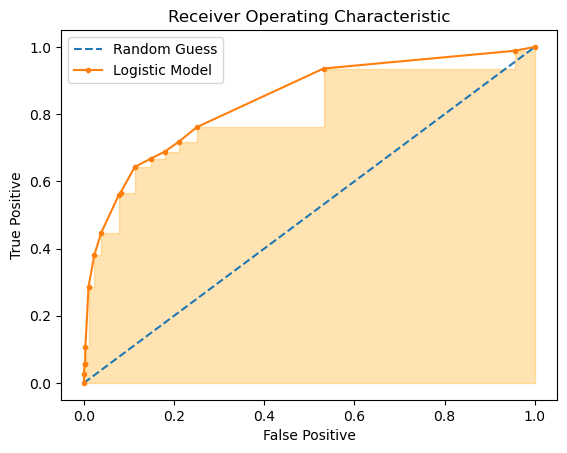

In [538]:
#Plotting the ROC curve:
log_y_prob = Model_DT.predict_proba(X_test)

#limiting the possibility of predicting ones:
log_y_prob = log_y_prob[:,1]

#Plotting the line where the true positives = False positives, the line is just random guess, and anything above is better


plt.plot([0,1], [0,1], linestyle="--", label= "Random Guess")

fpr, tpr, thres = roc_curve(y_test, log_y_prob)

plt.plot(fpr, tpr,marker=".", label = "Logistic Model")
plt.fill_between(fpr, tpr, step = "post", color="orange", alpha=.3)
plt.ylabel("True Positive")
plt.xlabel("False Positive")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()

In [539]:
AUC = round(roc_auc_score(y_test, log_y_prob), 4)
print("the area under the curve has a value of:", AUC)

the area under the curve has a value of: 0.8396


In [540]:
summary_dict= {"Model": ["model 3: Decicion Tree Classifier"],
               "Train Accuracy": [train_Acc],
               "Test Accuracy": [test_Acc],
               "AUC" : [AUC]}
Add_df = pd.DataFrame(summary_dict)
summary_df = pd.concat([summary_df, Add_df], ignore_index=True)

In [541]:
summary_df

,Model,Train Accuracy,Test Accuracy,AUC
0,Logistic Model 1,0.8091,0.7930,0.7511
1,Logistic Model 2,0.8056,0.7910,0.7436
2,model 2: Naive Bayes 1,0.8266,0.8095,0.8000
3,model 3: Decicion Tree Classifier,0.8590,0.8470,0.8396


en mer presis model her. høyere AUC, mer presise Accuracies

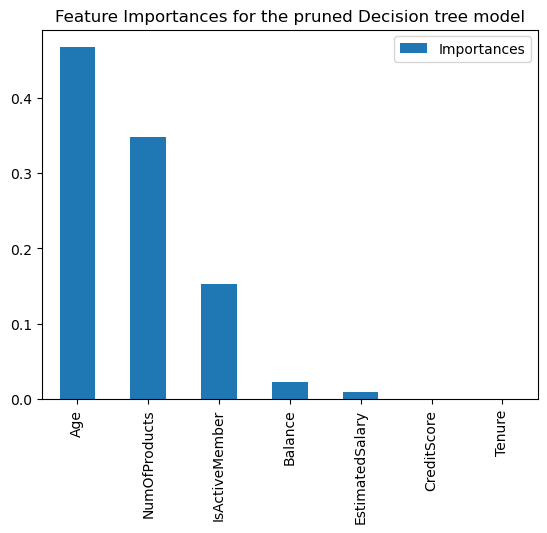

In [542]:
coefficients = []

for coeff in Model_DT.feature_importances_:
    coefficients.append(abs(coeff))

feature_importances = pd.DataFrame(coefficients, 
                                   index=X.columns, columns = ["Importances"])

feature_importances.sort_values(by=["Importances"],
                                axis=0, ascending = False, inplace=True)

feature_importances.head(7).plot(kind="bar")
plt.title("Feature Importances for the pruned Decision tree model")
plt.show()

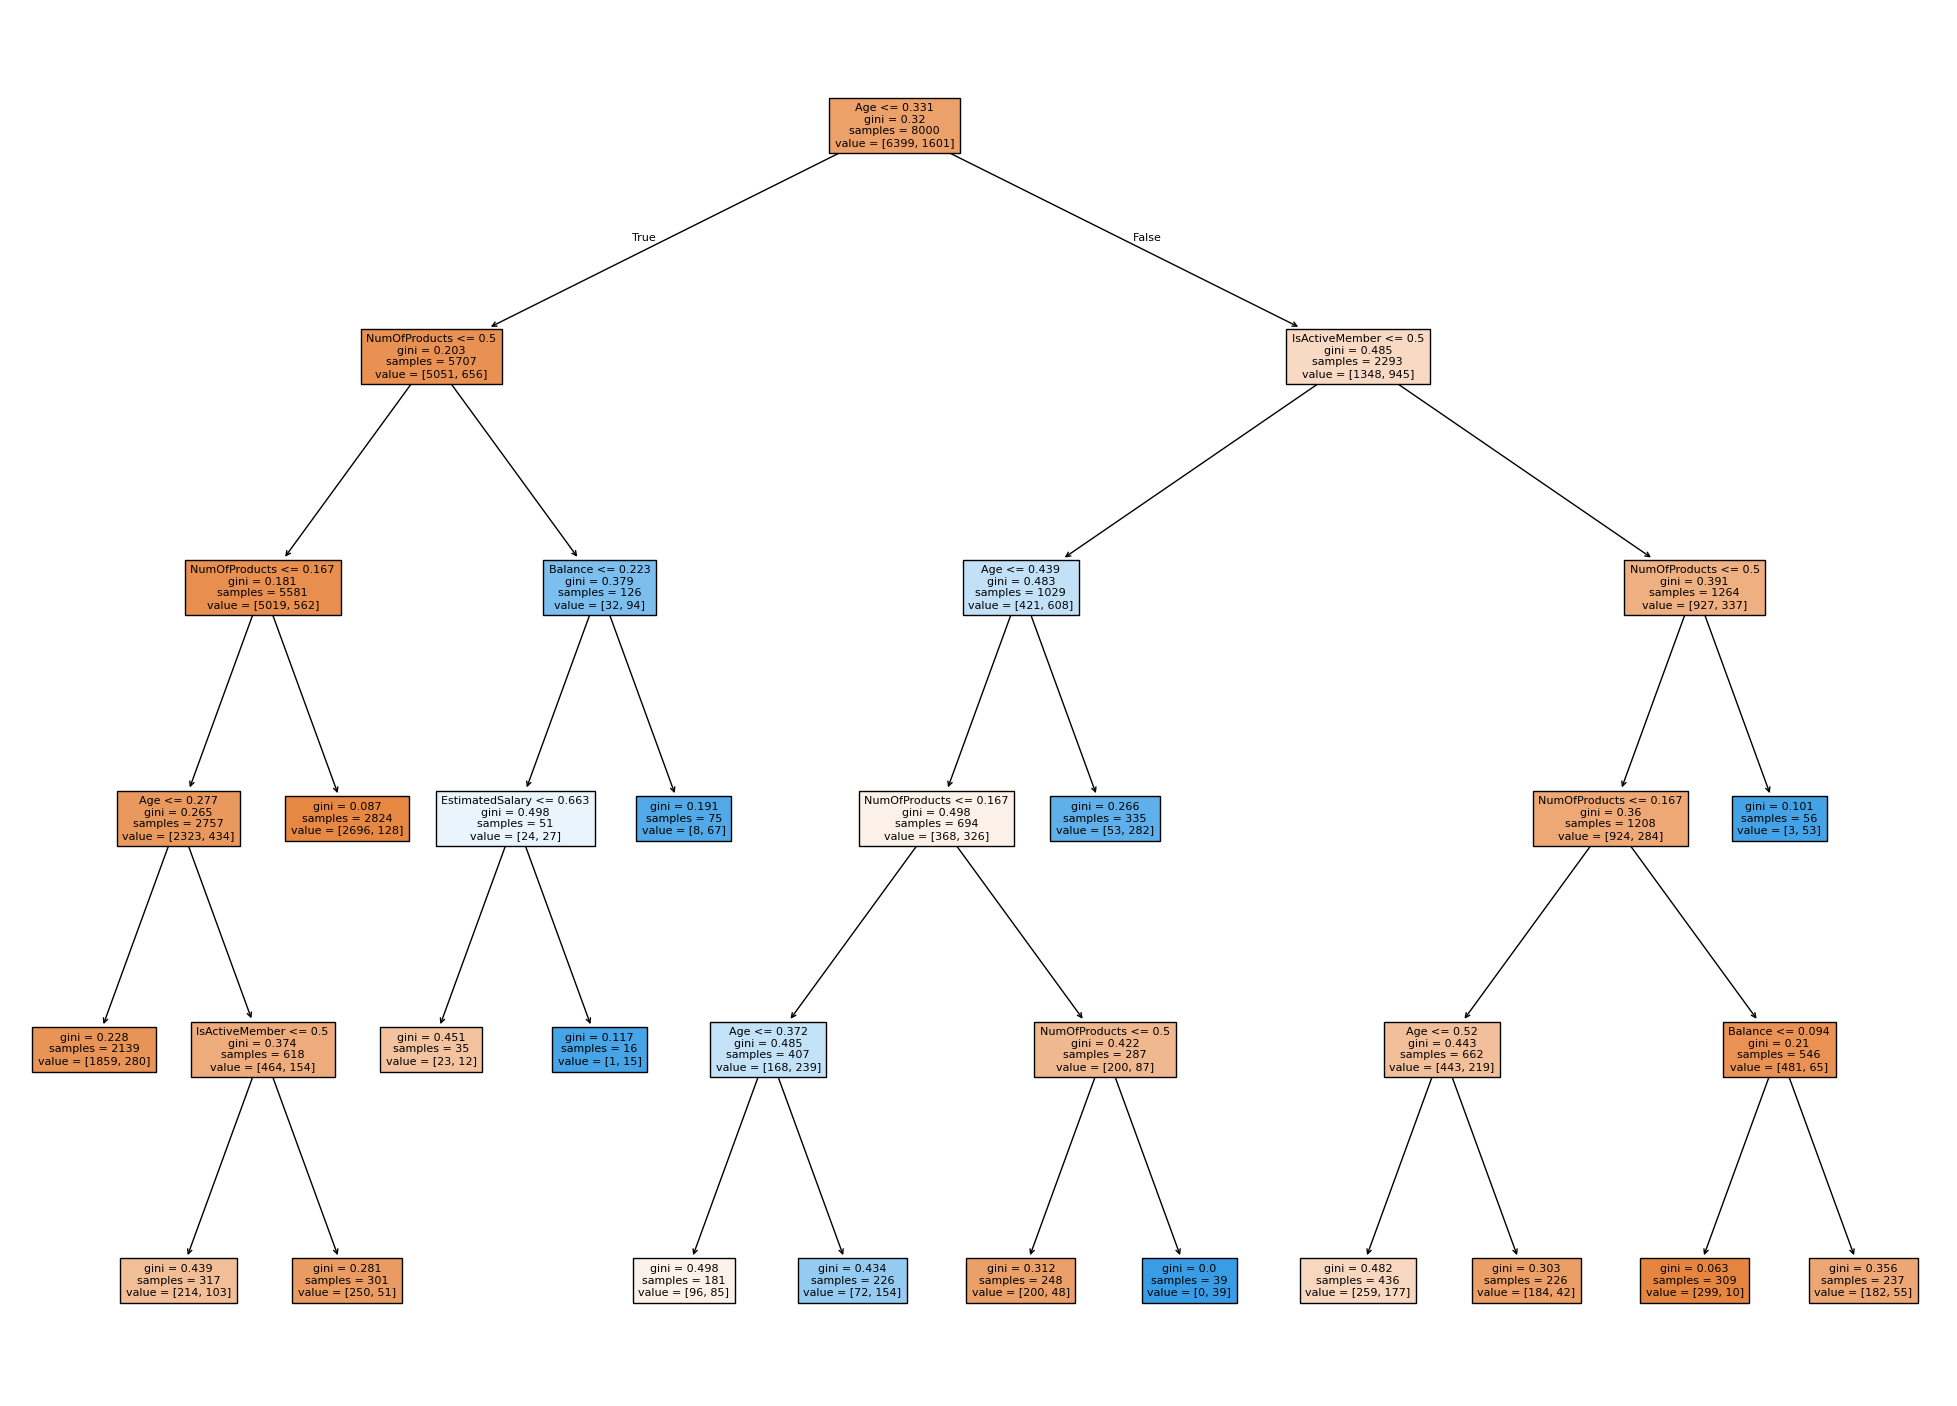

In [543]:
fig= plt.figure(figsize=(25,18))
plot_tree(Model_DT,
          feature_names=X.columns,
          filled = True,
          fontsize=8)
plt.show()